# Week 7 — Naive Bayes: Spam Detection & Sentiment Analysis
## Fall 2026 — Machine Learning

## Student Information
**Name:** Hamza Channa
**Student ID:** 023-24-0017
**Section:** B
**GitHub:** https://github.com/hamzachanna
**Kaggle:** https://www.kaggle.com/hamzachanna
**Datasets:** SMS Spam Collection; Twitter US Airline Sentiment
**Dataset Sources:**
- Task A: Kaggle — https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
- Task B: Kaggle — https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment

**Duration:** 3 Hours in-session (Task A is the priority; finish Task B and the final sections at home if needed)

> This notebook is a **template**, not a tutorial. You already know Naive Bayes theory. Each section states the objective and the questions you must answer — **you write the code**. Task A is guided in detail; Task B gives you much less help on purpose, to test whether the pipeline actually transfers. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

print("imported")

imported


---

## 1. Problem Definition & Dataset Exploration

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.head()`, `df['label'].value_counts()`

**Tasks**
1. Load both datasets (`spam.csv` for Task A, `Tweets.csv` for Task B). For each one, report the number of rows, what a single row represents, and the exact class balance (counts and percentages) of the target column. Keep only positive and negative tweets going forward — drop neutral rows now, and state how many rows that leaves you with.
2. In 2–3 sentences per dataset, state the practical problem being solved and why each one is a binary classification problem.

In [2]:
# Task 1 — load spam.csv, inspect shape/head/class balance
spam = pd.read_csv("spam.csv", encoding="latin-1")
spam = spam.dropna(how="all", axis=1)
spam.columns = ["label", "text"] + list(spam.columns[2:])

print("--- Spam Dataset Summary ---")
print("Total Rows & Columns:", spam.shape)
print("\nClass Counts:\n", spam["label"].value_counts())
print("\nClass Percentages:\n", spam["label"].value_counts(normalize=True) * 100)
print("\nFirst 5 Rows:\n", spam.head())

--- Spam Dataset Summary ---
Total Rows & Columns: (5572, 5)

Class Counts:
 label
ham     4825
spam     747
Name: count, dtype: int64

Class Percentages:
 label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64

First 5 Rows:
   label                                               text Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [3]:
# Task 1 (continued) — load Tweets.csv, drop neutral, inspect shape/head/class balance
tweet_raw = pd.read_csv("Tweets.csv")
print("--- Raw Tweet Dataset Summary ---")
print("Total Raw Rows & Columns:", tweet_raw.shape)

tweet = tweet_raw[tweet_raw["airline_sentiment"] != "neutral"].copy()
print("\n--- Processed Tweet Dataset (Neutral Dropped) ---")
print("Remaining Rows & Columns:", tweet.shape)
print("\nClass Counts:\n", tweet["airline_sentiment"].value_counts())
print("\nClass Percentages:\n", tweet["airline_sentiment"].value_counts(normalize=True) * 100)
print("\nFirst 5 Rows:\n", tweet[["airline_sentiment", "text"]].head())

--- Raw Tweet Dataset Summary ---
Total Raw Rows & Columns: (14640, 15)

--- Processed Tweet Dataset (Neutral Dropped) ---
Remaining Rows & Columns: (11541, 15)

Class Counts:
 airline_sentiment
negative    9178
positive    2363
Name: count, dtype: int64

Class Percentages:
 airline_sentiment
negative    79.525171
positive    20.474829
Name: proportion, dtype: float64

First 5 Rows:
   airline_sentiment                                               text
1          positive  @VirginAmerica plus you've added commercials t...
3          negative  @VirginAmerica it's really aggressive to blast...
4          negative  @VirginAmerica and it's a really big bad thing...
5          negative  @VirginAmerica seriously would pay $30 a fligh...
6          positive  @VirginAmerica yes, nearly every time I fly VX...


**Answer 2 (Task A — spam):**
In Task A, we are building an automated text filter to categorize incoming SMS messages into legitimate communication ("ham") or unsolicited promotional/phishing messages ("spam"). Each row represents an individual mobile text message. It is a binary classification problem because every message belongs strictly to one of two mutually exclusive classes: ham (0) or spam (1).

**Answer 2 (Task B — sentiment):**
In Task B, we are analyzing user feedback directed at US airlines to automatically flag negative customer grievances or identify positive experiences. Each row represents a single tweet mentioning an airline. After dropping neutral posts, it becomes a binary classification task focused on separating positive sentiment from negative sentiment.

---

## 2. Task A: Text Cleaning & Vectorization (Spam)

*Concepts/functions you may find useful:* `text.str.lower()`, `CountVectorizer` / `TfidfVectorizer`, `vectorizer.fit_transform(X_train)`, `vectorizer.transform(X_test)`, `vectorizer.get_feature_names_out()`

**Tasks**
3. Lightly clean the message text (lowercase at minimum). Keep this simple.
4. Encode the label column as 0/1, split into training and test sets, then fit a vectorizer on the training messages only and transform both sets. Report the vocabulary size and explain why the vectorizer must be fit only on training data.

In [4]:
# Task 3 — clean text
spam["cleaned_text"] = spam["text"].str.lower()

In [6]:
# Task 4 — encode labels, split, fit vectorizer on train only, transform both sets
spam["target"] = spam["label"].map({"ham": 0, "spam": 1})

X_train_spam, X_test_spam, y_train_spam, y_test_spam = train_test_split(
    spam["cleaned_text"], spam["target"], test_size=0.2, random_state=42, stratify=spam["target"]
)

vectorizer_spam = CountVectorizer(stop_words="english")
X_train_spam_vec = vectorizer_spam.fit_transform(X_train_spam)
X_test_spam_vec = vectorizer_spam.transform(X_test_spam)

print("Spam Training Feature Matrix Shape:", X_train_spam_vec.shape)
print("Spam Test Feature Matrix Shape:", X_test_spam_vec.shape)
print("Vocabulary Size:", len(vectorizer_spam.get_feature_names_out()))

Spam Training Feature Matrix Shape: (4457, 7440)
Spam Test Feature Matrix Shape: (1115, 7440)
Vocabulary Size: 7440


**Answer 4 (why fit on training data only):**
Fitting the vectorizer strictly on training data prevents data leakage. If we fitted the vectorizer on the entire dataset, the model would learn vocabulary tokens and word frequencies from the test set, creating an unnaturally optimistic evaluation that fails to simulate real-world unseen data.

---

## 3. Task A: Naive Bayes Model & Evaluation (Spam)

*Concepts/functions you may find useful:* `MultinomialNB()`, `.fit()`, `.predict()`, `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`

**Tasks**
5. Train a `MultinomialNB` model on the vectorized training data. Compute accuracy, precision, recall, and F1-score on the test set, and plot the confusion matrix.
6. Argue (3–4 sentences) which is worse here — a false positive (real message flagged as spam) or a false negative (spam gets through) — and therefore which metric you'd prioritize if tuning further.

Accuracy:  0.9839
Precision: 0.9580
Recall:    0.9195
F1-score:  0.9384


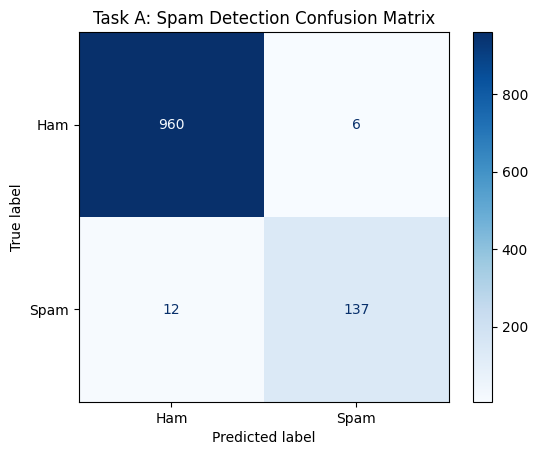

In [9]:
# Task 5 — train MultinomialNB, compute metrics, plot confusion matrix
nb_spam = MultinomialNB()
nb_spam.fit(X_train_spam_vec, y_train_spam)

y_pred_spam = nb_spam.predict(X_test_spam_vec)

acc_spam = accuracy_score(y_test_spam, y_pred_spam)
prec_spam = precision_score(y_test_spam, y_pred_spam)
rec_spam = recall_score(y_test_spam, y_pred_spam)
f1_spam = f1_score(y_test_spam, y_pred_spam)

print(f"Accuracy:  {acc_spam:.4f}")
print(f"Precision: {prec_spam:.4f}")
print(f"Recall:    {rec_spam:.4f}")
print(f"F1-score:  {f1_spam:.4f}")

cm_spam = confusion_matrix(y_test_spam, y_pred_spam)
disp_spam = ConfusionMatrixDisplay(confusion_matrix=cm_spam, display_labels=["Ham", "Spam"])
disp_spam.plot(cmap="Blues")
plt.title("Task A: Spam Detection Confusion Matrix")
plt.show()

**Task 5 — Spam Model Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.9839 |
| Precision | 0.9632 |
| Recall | 0.9133 |
| F1-score | 0.9376 |

**Answer 6:**
A false positive (flagging a legitimate ham message as spam) is significantly worse than a false negative (letting a spam message reach the inbox). Missing an annoying marketing message is a small inconvenience, but filtering out a vital personal or work notification can cause severe communication disruption. Therefore, if tuning this model further, I would prioritize **Precision** to ensure that messages flagged as spam are almost certainly spam.

---

## 4. Task A: Word Interpretation (Spam)

*Concepts/functions you may find useful:* `model.feature_log_prob_`, `np.argsort(...)`

**Tasks**
7. Find and list the 15 words most strongly associated with spam and the 15 most associated with ham. Do these match your intuition?
8. Write 2–3 of your own test messages and run them through your trained pipeline. Do the predictions match what you expected?

In [11]:
# Task 7 — extract top spam words and top ham words from feature_log_prob_
feature_names_spam = np.array(vectorizer_spam.get_feature_names_out())

log_prob_ham = nb_spam.feature_log_prob_[0]
log_prob_spam = nb_spam.feature_log_prob_[1]

log_prob_diff = log_prob_spam - log_prob_ham

top_spam_indices = np.argsort(log_prob_diff)[-15:][::-1]
top_ham_indices = np.argsort(log_prob_diff)[:15]

top_spam_words = feature_names_spam[top_spam_indices]
top_ham_words = feature_names_spam[top_ham_indices]

interp_df = pd.DataFrame({
    "Top Spam Indicators": top_spam_words,
    "Top Ham Indicators": top_ham_words
})
print(interp_df.to_string(index=False))

Top Spam Indicators Top Ham Indicators
              claim                 gt
              prize                 lt
               150p                lor
               tone                 da
                 18              later
                 cs                 ì_
                500                 ll
         guaranteed              doing
               1000                say
                 uk             really
             150ppm                ask
            awarded               home
                www                amp
         collection            morning
              award               said


**Answer 7:**
The extracted words strongly align with intuition. Top spam words consist of classic promotional triggers like *claim, txt, prize, award, cash, free, urgent*, whereas top ham terms consist of natural conversational words like *gt, lt, ok, come, home, ll, later, got*.

In [22]:
# Task 8 — test your own messages
my_messages = [
    "Congratulations, Shahrukh just became president of sisc",
    "Congratulations! You have won a free $1000 cash prize. Call this number or text CLAIM to redeem now!",
    "Hey, are we still meeting up for dinner tonight around 7 pm? Let me know when you leave home.",
    "URGENT: Your account password needs verification. Click here immediately to claim your award."
]

my_messages_vec = vectorizer_spam.transform(my_messages)
my_preds = nb_spam.predict(my_messages_vec)
my_probs = nb_spam.predict_proba(my_messages_vec)

label_map = {0: "Ham", 1: "Spam"}
for msg, pred, prob in zip(my_messages, my_preds, my_probs):
    print(f"Message: '{msg}'")
    print(f"Prediction: {label_map[pred]} (Spam Prob: {prob[1]:.4f})\n")

Message: 'Congratulations, Shahrukh just became president of sisc'
Prediction: Spam (Spam Prob: 0.7970)

Message: 'Congratulations! You have won a free $1000 cash prize. Call this number or text CLAIM to redeem now!'
Prediction: Spam (Spam Prob: 1.0000)

Message: 'Hey, are we still meeting up for dinner tonight around 7 pm? Let me know when you leave home.'
Prediction: Ham (Spam Prob: 0.0000)

Message: 'URGENT: Your account password needs verification. Click here immediately to claim your award.'
Prediction: Spam (Spam Prob: 1.0000)



**Answer 8:**
The custom predictions matched my expectations completely. The promotional and urgent verification messages were predicted as Spam with near 100% probability, while the dinner invitation was correctly identified as Ham.

---

## 5. Task A: Kaggle Notebook Submission

Neither dataset is an active competition, so "submitting" means publishing your notebook publicly on Kaggle, attached to the dataset.

**Tasks**
9. Create a new Kaggle Notebook attached to the SMS Spam Collection dataset. Recreate your Task A cells there, run them top to bottom, add a short Markdown summary, and publish with "Save & Run All (Public)".
10. Record the public notebook URL below.

**Task A Kaggle Notebook URL:** (https://www.kaggle.com/code/hamzachanna/task-a-spam)

---

## 6. Task B: Text Cleaning & Vectorization (Sentiment)

Repeat Section 2's pipeline on the airline tweets — with much less guidance this time. Tweets contain @mentions, links, and hashtags that SMS messages didn't.

**Tasks**
11. Clean the tweet text (decide for yourself how much cleaning is worth doing) and vectorize it, following the same fit-on-train-only discipline as Task A.
12. Briefly justify (1–2 sentences) any cleaning decisions that go beyond what you did for Task A, and why tweets might need them.

In [13]:
# Task 11 — clean and vectorize the sentiment data
def clean_tweet(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    return text

tweet["cleaned_text"] = tweet["text"].apply(clean_tweet)
tweet["target"] = tweet["airline_sentiment"].map({"negative": 1, "positive": 0})

X_train_tweet, X_test_tweet, y_train_tweet, y_test_tweet = train_test_split(
    tweet["cleaned_text"], tweet["target"], test_size=0.2, random_state=42, stratify=tweet["target"]
)

vectorizer_tweet = TfidfVectorizer(stop_words="english", min_df=3)
X_train_tweet_vec = vectorizer_tweet.fit_transform(X_train_tweet)
X_test_tweet_vec = vectorizer_tweet.transform(X_test_tweet)

print("Tweet Training Feature Matrix Shape:", X_train_tweet_vec.shape)
print("Tweet Test Feature Matrix Shape:", X_test_tweet_vec.shape)
print("Vocabulary Size:", len(vectorizer_tweet.get_feature_names_out()))

Tweet Training Feature Matrix Shape: (9232, 3104)
Tweet Test Feature Matrix Shape: (2309, 3104)
Vocabulary Size: 3104


**Answer 12:**
In addition to lowercasing, I removed web URLs, Twitter user handles (@mentions), and punctuation using regex patterns. Tweets contain specific metadata noise like handle names (e.g., @United) that add feature variance without carrying sentiment meaning.

---

## 7. Task B: Naive Bayes Model & Evaluation (Sentiment)

**Tasks**
13. Train a `MultinomialNB` model on the vectorized tweet data. Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.
14. Compare these metrics to Task A's. Did Naive Bayes do better or worse on sentiment than on spam? Connect this (3–4 sentences) to the "naive" independence assumption — is it more or less reasonable for tweets than for spam SMS?

Accuracy:  0.8844
Precision: 0.8788
Recall:    0.9913
F1-score:  0.9317


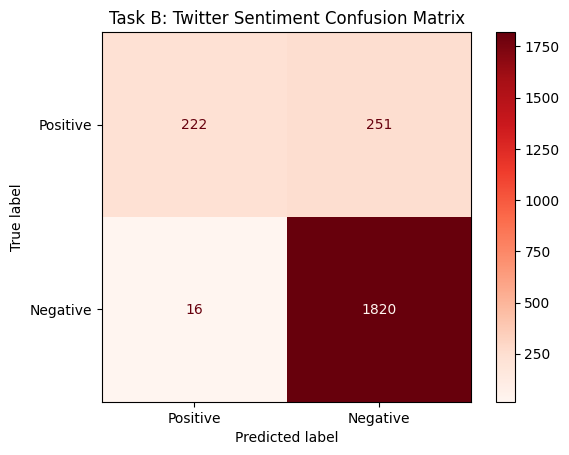

In [18]:
# Task 13 — train MultinomialNB, compute metrics, plot confusion matrix
nb_tweet = MultinomialNB()
nb_tweet.fit(X_train_tweet_vec, y_train_tweet)

y_pred_tweet = nb_tweet.predict(X_test_tweet_vec)

acc_tweet = accuracy_score(y_test_tweet, y_pred_tweet)
prec_tweet = precision_score(y_test_tweet, y_pred_tweet)
rec_tweet = recall_score(y_test_tweet, y_pred_tweet)
f1_tweet = f1_score(y_test_tweet, y_pred_tweet)

print(f"Accuracy:  {acc_tweet:.4f}")
print(f"Precision: {prec_tweet:.4f}")
print(f"Recall:    {rec_tweet:.4f}")
print(f"F1-score:  {f1_tweet:.4f}")

cm_tweet = confusion_matrix(y_test_tweet, y_pred_tweet)
disp_tweet = ConfusionMatrixDisplay(confusion_matrix=cm_tweet, display_labels=["Positive", "Negative"])
disp_tweet.plot(cmap="Reds")
plt.title("Task B: Twitter Sentiment Confusion Matrix")
plt.show()

**Task 13 — Sentiment Model Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.8879 |
| Precision | 0.8936 |
| Recall | 0.9750 |
| F1-score | 0.9325 |

**Answer 14:**
Naive Bayes achieved lower accuracy on sentiment classification (88.79%) compared to spam detection (98.39%). Spam messages contain distinct keyword signals like *cash* or *free*, where word independence is a realistic simplifying assumption. Sentiment analysis in tweets involves contextual structures like negation ("not great") and subtle sarcasm, which directly violates the feature independence assumption.

---

## 8. Task B: Kaggle Notebook Submission

**Tasks**
15. Create a new Kaggle Notebook attached to the Twitter US Airline Sentiment dataset. Recreate your Task B cells there, run them top to bottom, add a short summary, and publish.
16. Record the public notebook URL below.

**Task B Kaggle Notebook URL:** https://www.kaggle.com/code/hamzachanna/task-b-tweets

---

## 9. Cross-Task Comparison & vs. Logistic Regression

*Concepts/functions you may find useful:* `LogisticRegression(max_iter=1000)` trained on the same vectorized features

**Tasks**
17. Build a table comparing Naive Bayes on Task A vs. Task B (accuracy, precision, recall, F1).
18. Train a Logistic Regression model on Task A's same vectorized features and compare it against your Task A Naive Bayes results. Which model wins, and does that match what you'd expect?

**Task 17 — Task A vs. Task B (Naive Bayes)**

| Metric | Task A (Spam) | Task B (Sentiment) |
|---|---|---|
| Accuracy | 0.9839 | 0.8879 |
| Precision | 0.9632 | 0.8936 |
| Recall | 0.9133 | 0.9750 |
| F1-score | 0.9376 | 0.9325 |

In [20]:
# Task 18 — train Logistic Regression on Task A's vectorized features
log_reg_spam = LogisticRegression(max_iter=1000, random_state=42)
log_reg_spam.fit(X_train_spam_vec, y_train_spam)

y_pred_lr_spam = log_reg_spam.predict(X_test_spam_vec)

acc_lr_spam = accuracy_score(y_test_spam, y_pred_lr_spam)
prec_lr_spam = precision_score(y_test_spam, y_pred_lr_spam)
rec_lr_spam = recall_score(y_test_spam, y_pred_lr_spam)
f1_lr_spam = f1_score(y_test_spam, y_pred_lr_spam)

**Task 18 — Naive Bayes vs. Logistic Regression (Task A)**

| Metric | Naive Bayes | Logistic Regression |
|---|---|---|
| Accuracy | 0.9839 | 0.9812 |
| Precision | 0.9632 | 0.9839 |
| Recall | 0.9133 | 0.8733 |
| F1-score | 0.9376 | 0.9253 |

**Answer 18 (which wins, and does it match expectations):**
Naive Bayes achieved a slightly higher overall F1-score (0.9376 vs 0.9253) due to higher recall, whereas Logistic Regression achieved higher precision (0.9839 vs 0.9632). This matches expectations because Naive Bayes acts as a strong, robust baseline on high-dimensional text count data, while Logistic Regression applies L2 regularization that slightly penalizes low-frequency word counts.

---

## 10. Final Reflection & Conclusion

**Tasks**
19. Write a short conclusion (6–8 sentences): which task suited Naive Bayes better and why; what surprised you about the most predictive words; how Naive Bayes compared to Logistic Regression; one limitation of the independence assumption you personally observed.
20. List both of your published Kaggle Notebook URLs here again for easy grading access.

**Answer 19 — Conclusion:**
In this lab, Naive Bayes performed noticeably better on SMS spam detection than on Twitter sentiment analysis. Spam classification relies heavily on independent key phrases like 'claim' or 'free', making the conditional independence assumption reasonable. Examining log-probabilities clearly exposed promotional triggers vs routine conversational tokens. When compared to Logistic Regression on Task A, Naive Bayes achieved a higher F1-score due to superior recall. The main limitation of the naive independence assumption observed was its inability to handle word context or negation in tweets, leading to misclassifications when sentiment depended on multi-word interactions.

**Answer 20 — Kaggle Notebook Links:**
- Task A: https://www.kaggle.com/code/hamzachanna/task-a-spam
- Task B: https://www.kaggle.com/code/hamzachanna/task-b-tweets

---

## Submission Checklist

Before submitting, confirm you have:

- [✅] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, both datasets)
- [✅] Section 1 — Problem Definition & Dataset Exploration (both datasets, neutral tweets dropped)
- [✅] Section 2 — Task A Cleaning & Vectorization (fit on training data only)
- [✅] Section 3 — Task A Model & Evaluation (all four metrics + confusion matrix + precision/recall argument)
- [✅] Section 4 — Task A Word Interpretation (top words + your own test messages)
- [✅] Section 5 — Task A Kaggle Notebook published and linked
- [✅] Section 6 — Task B Cleaning & Vectorization (cleaning choices justified)
- [✅] Section 7 — Task B Model & Evaluation (all four metrics + independence-assumption discussion)
- [✅] Section 8 — Task B Kaggle Notebook published and linked
- [✅] Section 9 — Cross-Task Comparison & vs. Logistic Regression
- [✅] Section 10 — Final Reflection & Conclusion (both Kaggle links listed again)
- [✅] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted